In [1]:
from clans3d.evaluation.scores_evaluator import ScoresEvaluator
from clans3d.core.input_file_type import InputFileType
from clans3d.similarity.tool_type import ToolType
import pandas as pd

In [2]:
WORKING_DIR = "../work/scores_evaluation_files"
EXAMPLE_DATASET_FASTA = "../examples/small_fasta_files/50.fasta"
EXAMPLE_DATASET_TSV = "../examples/big_tsv_files/1500.tsv"

In [3]:
evaluator = ScoresEvaluator(WORKING_DIR)

In [4]:
# Generate clans files from example dataset
clans_files = evaluator.generate_clans_files(EXAMPLE_DATASET_FASTA, InputFileType.FASTA, ToolType.FOLDSEEK, "evalue")
print(clans_files)

Failed to download A0A836ZK00 from https://alphafold.ebi.ac.uk/api/prediction/A0A836ZK00
Failed to download A0A2W5V1G2 from https://alphafold.ebi.ac.uk/api/prediction/A0A2W5V1G2
Failed to download A0A0F0DHL0 from https://alphafold.ebi.ac.uk/api/prediction/A0A0F0DHL0
Failed to download A0A3R8VQN3 from https://alphafold.ebi.ac.uk/api/prediction/A0A3R8VQN3
Failed to download A0A2N3H2V6 from https://alphafold.ebi.ac.uk/api/prediction/A0A2N3H2V6
Failed to download A0A7G7RI23 from https://alphafold.ebi.ac.uk/api/prediction/A0A7G7RI23
Failed to download A0A1H9LII5 from https://alphafold.ebi.ac.uk/api/prediction/A0A1H9LII5
Failed to download A0A8B3GD31 from https://alphafold.ebi.ac.uk/api/prediction/A0A8B3GD31
Failed to download A0A1L7G3J5 from https://alphafold.ebi.ac.uk/api/prediction/A0A1L7G3J5
Failed to download A0A7Y1FHL4 from https://alphafold.ebi.ac.uk/api/prediction/A0A7Y1FHL4
Failed to download A0A550F895 from https://alphafold.ebi.ac.uk/api/prediction/A0A550F895
Failed to download A0

FASTA-Reader: Ignoring invalid residues at position(s): On line 5: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 8: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 11: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 14: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 17: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 20: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 23: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 26: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 29: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 32: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 35: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 38: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 41: 1-2
FASTA-Reader: Ignoring invalid residues at position(s): On line 44

Generating CLANS file ../work/scores_evaluation_files/50_cleaned_seq.clans...
CLANS file generated at ../work/scores_evaluation_files/50_cleaned_seq.clans
('../work/scores_evaluation_files/clans_files/50_cleaned.clans', '../work/scores_evaluation_files/50_cleaned_seq.clans')


In [23]:
# Parameters for clustering with recovered clans.jar The first entry in each tuple is for structure-based clans, the second for sequence-based clans.
PATH_TO_CLANS_JAR = "../src/clans3d/legacy/clans_working_version.jar" # path to clans jar file
CLUSTER_ROUNDS: tuple[int, int] = (1000, 1000) # sets the number of rounds for clustering in recovered clans
P_VALUES: tuple[float, float] = (1E-10, 1E-10) # sets the p-value threshold for clustering in recovered clans for (structure, sequence)
CLUSTER_2D: tuple[bool, bool] = (False, False) # whether to use 2D clustering in recovered clans
VERBOSE: bool = True # whether to print verbose output from recovered clans

In [24]:
# Cluster the generated clans files
clustered_clans_files = evaluator.cluster_clans_files(PATH_TO_CLANS_JAR, clans_files, CLUSTER_ROUNDS, P_VALUES, CLUSTER_2D, VERBOSE)
print(clustered_clans_files)


running with -nographics T -load ../work/scores_evaluation_files/50_cleaned.clans -dorounds 1000 -saveto ../work/scores_evaluation_files/50_cleaned_clustered_r_1000_p_1e-10.clans -pval 1e-10 -cluster2d F -verbose 1
Could not read config file. Continuing without.
config file reader not implemented
/home/aronw/Development/Clans-3D/notebooks/../work/scores_evaluation_files/50_cleaned.clans
used/total HSPs at threshold   1E-10: 0/0 (   NaN%)
LOADING data from '/home/aronw/Development/Clans-3D/notebooks/../work/scores_evaluation_files/50_cleaned.clans'
sequences=33
      528
total HSPs: 528
used/total HSPs at threshold     1E0: 528/528 (100.00%)
used/total HSPs at threshold   1E-10: 409/528 ( 77.46%)
done clustering round 0
Iteration 0
done clustering round 1000
Iterations complete. Saving.
Successfully saved to '/home/aronw/Development/Clans-3D/notebooks/../work/scores_evaluation_files/50_cleaned_clustered_r_1000_p_1e-10.clans'

running with -nographics T -load ../work/scores_evaluation_f

In [ ]:
# from here is use already clustered clans files for evaluation
evaluator = ScoresEvaluator(WORKING_DIR)
clustered_clans_files = ("../work/scores_evaluation_files/500_cleaned_clustered_r_10000_p_1e-10.clans",
                         "../work/scores_evaluation_files/500_cleaned_seq_clustered_r_10000_p_1e-29.clans")

In [26]:
# Extract data from clustered CLANS files
df_scores, df_euclidean_dist, df_coord = evaluator.extract_data_from_clans_files(clustered_clans_files)
display(df_scores.head())
display(df_euclidean_dist.head())
display(df_coord.head())


Evaluating clustered clans files: ../work/scores_evaluation_files/500_cleaned_clustered_r_10000_p_1e-10.clans and ../work/scores_evaluation_files/500_cleaned_seq_clustered_r_10000_p_1e-29.clans
Parsing CLANS file ../work/scores_evaluation_files/500_cleaned_clustered_r_10000_p_1e-10.clans...
Parsing CLANS file ../work/scores_evaluation_files/500_cleaned_seq_clustered_r_10000_p_1e-29.clans...


,Sequence_ID_1,Sequence_ID_2,Score_struct,Score_-log10_struct,Score_seq,Score_-log10_seq
0,A0A010TDP2,A0A0C5ERJ6,6.898000e-11,10.161277,1.270000e-49,48.896196
1,A0A010TDP2,A0A0D5XUC7,6.622000e-11,10.179011,1.270000e-49,48.896196
2,A0A010TDP2,A0A0D6SYC0,1.373000e-10,9.862329,1.290000e-46,45.889410
3,A0A010TDP2,A0A0F4VEF5,6.622000e-11,10.179011,1.270000e-49,48.896196
4,A0A010TDP2,A0A0J6GDG7,6.898000e-11,10.161277,1.270000e-49,48.896196


,Sequence_ID_1,Sequence_ID_2,euclidean_dist_struct,euclidean_dist_min_max_struct,euclidean_dist_seq,euclidean_dist_min_max_seq
0,C5BN68,A0A559QIZ0,48.038396,0.384708,0.995627,0.010808
1,C5BN68,A0A1Y6BVX3,86.937196,0.697035,1.408443,0.015942
2,C5BN68,Q21FA0,64.267181,0.515012,1.156397,0.012807
3,C5BN68,A0A0T6UN99,85.232253,0.683346,78.579009,0.975781
4,C5BN68,A0A1I3MH02,58.045481,0.465057,78.147779,0.970418


,Sequence_ID,x_struct,y_struct,z_struct,x_seq,y_seq,z_seq
0,A0A010TDP2,-14.461457,-4.747086,7.944270,-10.997788,13.678843,-2.137219
1,A0A023WWI9,13.610619,6.370728,-56.507980,-10.295343,13.362184,-2.018916
2,A0A024EET1,-15.353390,-4.605057,8.372849,-10.517995,14.122930,-1.159340
3,A0A024HPB1,-14.690795,-5.602873,8.212835,-9.950043,14.310882,-1.445684
4,A0A031G2U6,-14.311031,-4.125452,8.489697,-10.691348,13.630973,-1.850832


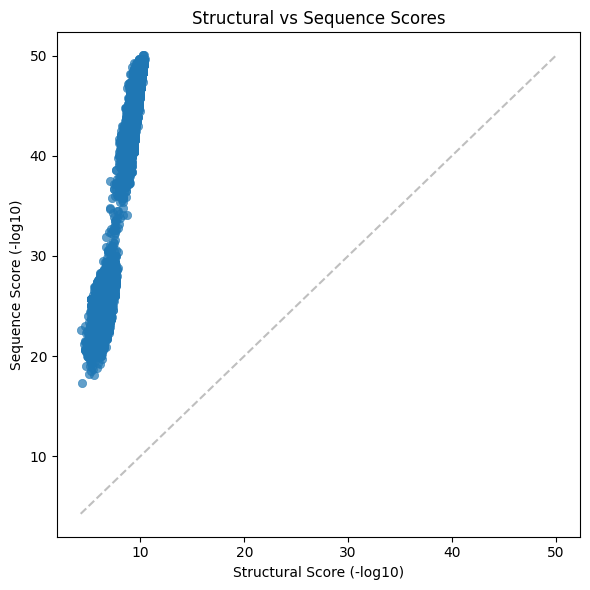

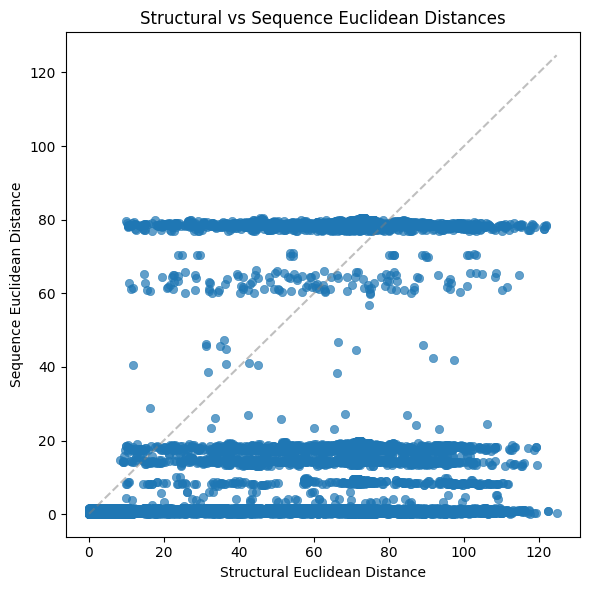

In [27]:
# Generate scatter plots to visualize relationships between scores and euclidian-distances
evaluator.visualizer.generate_scatter_plot(
    data_x=df_scores["Score_-log10_struct"],
    data_y=df_scores["Score_-log10_seq"],
    x_label="Structural Score (-log10)",
    y_label="Sequence Score (-log10)",
    title="Structural vs Sequence Scores"
)

evaluator.visualizer.generate_scatter_plot(
    data_x=df_euclidean_dist["euclidean_dist_struct"],
    data_y=df_euclidean_dist["euclidean_dist_seq"],
    x_label="Structural Euclidean Distance",
    y_label="Sequence Euclidean Distance",
    title="Structural vs Sequence Euclidean Distances"
)

### Interpretation of plots

1: kind of linear but sequence based evalues seem a lot more optimistic than structure based evalues

2: bands show that structural distance seems to be very different whereas sequence distance stays similar

In [28]:
# Find clusters using density-based and graph-based methods
RESOLUTION_PARAMS = (1.007, 1.01)  # (structure, sequence)
df_cluster_labels = evaluator.clustering.find_clusters_density_based(df_coord, "struct")
df_cluster_labels = df_cluster_labels.merge(evaluator.clustering.find_clusters_density_based(df_coord, "seq"), on="Sequence_ID")
df_Leiden_labels = evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_struct", resolution=RESOLUTION_PARAMS[0])
df_Leiden_labels = df_Leiden_labels.merge(evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_seq", resolution=RESOLUTION_PARAMS[1]), on="Sequence_ID")
df_cluster_labels = df_cluster_labels.merge(df_Leiden_labels, on="Sequence_ID")
display(df_cluster_labels)

,Sequence_ID,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden
0,A0A010TDP2,4,2,0,0
1,A0A023WWI9,0,2,1,1
2,A0A024EET1,4,2,0,0
3,A0A024HPB1,4,2,2,2
4,A0A031G2U6,4,2,0,0
...,...,...,...,...,...
488,V9V7Z7,4,2,0,0
489,W6QRK7,-1,2,1,1
490,W6VLX3,4,2,0,0
491,W7QD92,6,1,1,1


In [48]:
# Display number of clusters and noise found by each method

struct_hdbscan_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_struct_HDBSCAN")
seq_hdbscan_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_seq_HDBSCAN")
struct_leiden_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden")
seq_leiden_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_Score_-log10_seq_Leiden")

# expected number of clusters in clans file (500) struct visually 4 - 5
# expected number of clusters in clans file (500) seq visually 3
data_for_plot = {
    'HDBSCAN (Struct)': struct_hdbscan_counts,
    'HDBSCAN (Seq)': seq_hdbscan_counts,
    'Leiden (Struct)': struct_leiden_counts,
    'Leiden (Seq)': seq_leiden_counts
}
df_found_clusters = pd.DataFrame(data_for_plot)
display(df_found_clusters)

,HDBSCAN (Struct),HDBSCAN (Seq),Leiden (Struct),Leiden (Seq)
num_clusters,7,3,5,3
num_noise,46,0,0,0
num_clustered,447,493,493,493


### Interpretation

The clustering of the structural file seems to have produced more clusters than the clustering on the sequence file.

Density and network based methods seem to agree on clustered sequence file

In [49]:
# Compute ARI and NMI between structure-based and sequence-based clusterings
clustering_agreement_HDBSCAN = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN")
clustering_agreement_Leiden = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden")
print(f"Clustering agreement (HDBSCAN): ARI={clustering_agreement_HDBSCAN['ARI']}, NMI={clustering_agreement_HDBSCAN['NMI']}")
print(f"Clustering agreement (Leiden): ARI={clustering_agreement_Leiden['ARI']}, NMI={clustering_agreement_Leiden['NMI']}")

Clustering agreement (HDBSCAN): ARI=0.10164189659601484, NMI=0.113448791423154
Clustering agreement (Leiden): ARI=0.9679424999000981, NMI=0.9362835568848873


### Interpretation

ari and nmi with hdbscan very low while very high with network based clustering?

weird

Maybe because hdbscan found a lot more clusters then the network based method

In [52]:
# Compute Jaccard overlap between structure-based and sequence-based clusterings
jaccard_results_HDBSCAN = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN", remove_zero_jaccard=False)
jaccard_results_Leiden = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden", remove_zero_jaccard=False)
print("Jaccard Overlap Results (HDBSCAN - structure vs sequence):")
display(jaccard_results_HDBSCAN)
print("Jaccard Overlap Results (Leiden - structure vs sequence):")
display(jaccard_results_Leiden)


Jaccard Overlap Results (HDBSCAN - structure vs sequence):


,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,JaccardIndex
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.064965
3,1,0,0.000000
4,1,1,0.000000
5,1,2,0.076566
6,2,0,0.000000
7,2,1,0.000000
8,2,2,0.030162
9,3,0,0.000000


Jaccard Overlap Results (Leiden - structure vs sequence):


,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden,JaccardIndex
0,0,0,0.986885
1,0,1,0.000000
2,0,2,0.000000
3,1,0,0.000000
4,1,1,0.978610
5,1,2,0.000000
6,2,0,0.000000
7,2,1,0.015957
8,2,2,0.250000
9,3,0,0.013115


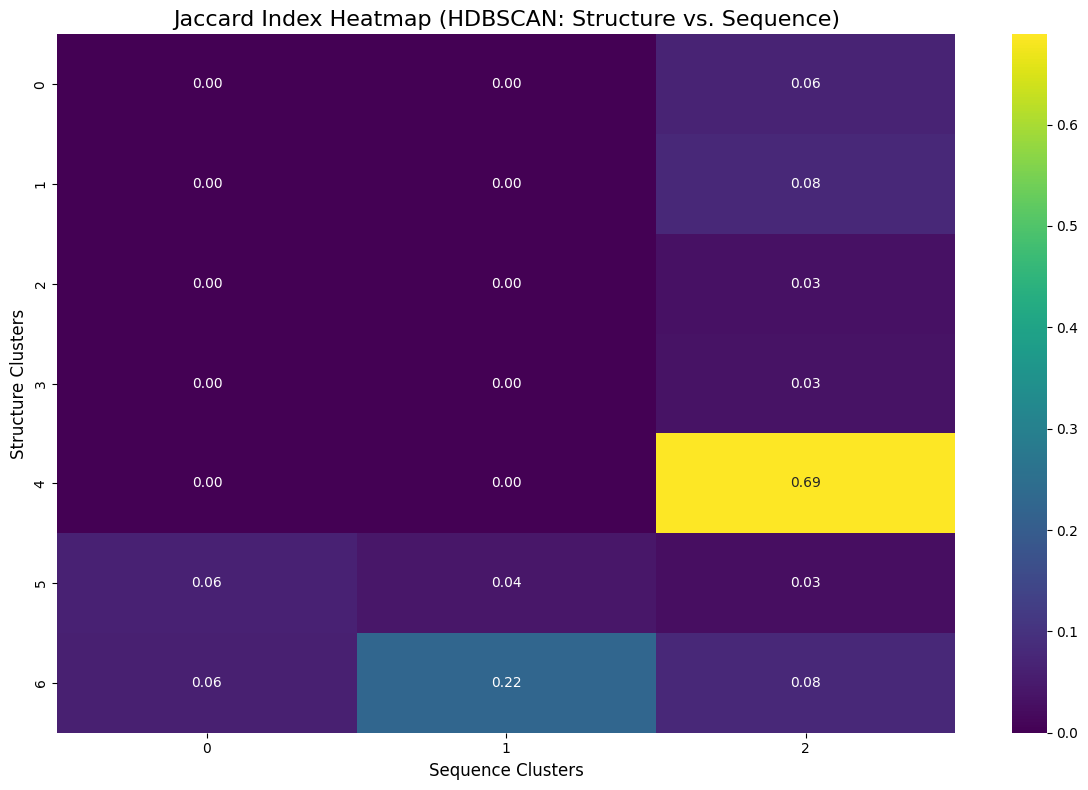

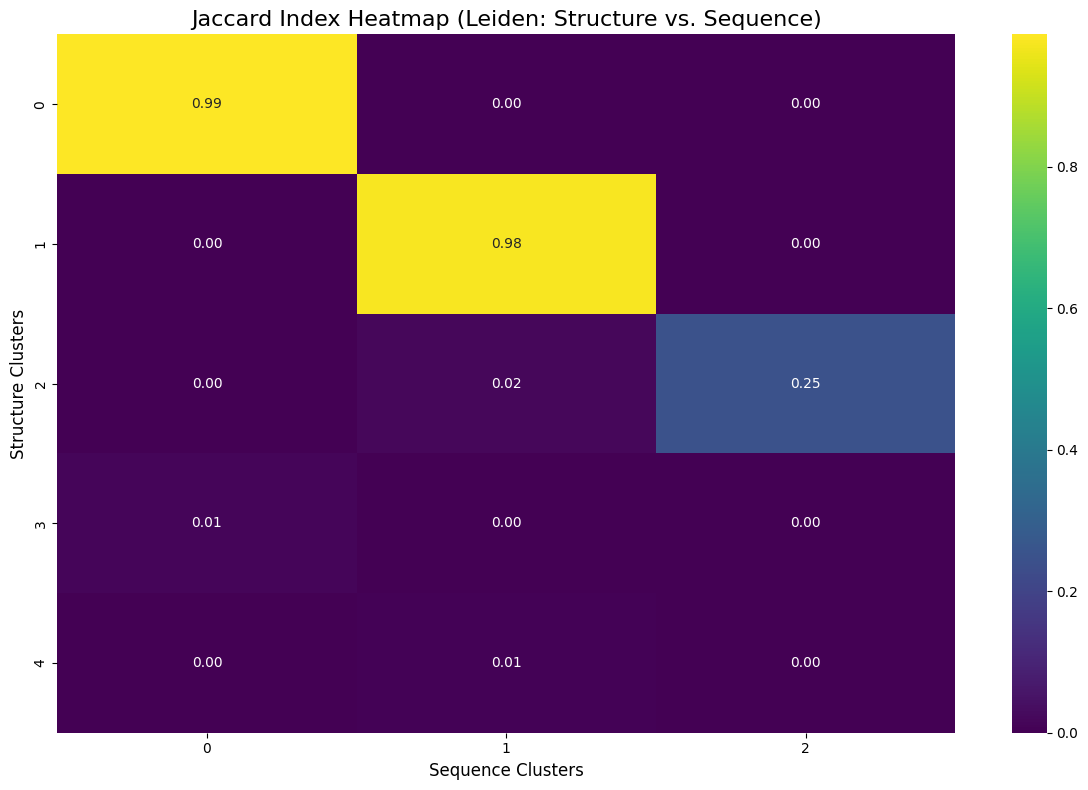

In [54]:
# Heatmap for Jaccard indices from HDBSCAN clustering
jaccard_pivot_hdb = jaccard_results_HDBSCAN.pivot(
    index='cluster_id_struct_HDBSCAN',
    columns='cluster_id_seq_HDBSCAN',
    values='JaccardIndex'
)
evaluator.visualizer.generate_heatmap(
    pivot_table=jaccard_pivot_hdb,
    title='Jaccard Index Heatmap (HDBSCAN: Structure vs. Sequence)',
    x_label='Sequence Clusters',
    y_label='Structure Clusters'
)

# Heatmap for Jaccard indices from Leiden clustering
jaccard_pivot_l = jaccard_results_Leiden.pivot(
    index='cluster_id_Score_-log10_struct_Leiden',
    columns='cluster_id_Score_-log10_seq_Leiden',
    values='JaccardIndex'
)
evaluator.visualizer.generate_heatmap(
    pivot_table=jaccard_pivot_l,
    title='Jaccard Index Heatmap (Leiden: Structure vs. Sequence)',
    x_label='Sequence Clusters',
    y_label='Structure Clusters'
)

### Interpretation

The Jaccard index should show me there are structural clusters very similar to sequence clusters.

In [57]:
# Compute overlap coefficient between structure-based and sequence-based clusterings
overlap_coefficient_HDBSCAN = evaluator.clustering.compute_overlap_coefficient(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN", drop_zero=False)
overlap_coefficient_Leiden = evaluator.clustering.compute_overlap_coefficient(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden", drop_zero=False)
print("Overlap Coefficient Results (HDBSCAN - structure vs sequence):")
display(overlap_coefficient_HDBSCAN)
print("Overlap Coefficient Results (Leiden - structure vs sequence):")
display(overlap_coefficient_Leiden)

Overlap Coefficient Results (HDBSCAN - structure vs sequence):


,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,OverlapCoefficient,is_smaller
0,0,1,0.000000,cluster_id_seq_HDBSCAN
1,0,2,1.000000,cluster_id_struct_HDBSCAN
2,1,0,0.000000,cluster_id_seq_HDBSCAN
3,1,2,1.000000,cluster_id_struct_HDBSCAN
4,2,0,0.000000,cluster_id_seq_HDBSCAN
5,2,1,0.000000,cluster_id_seq_HDBSCAN
6,3,0,0.000000,cluster_id_seq_HDBSCAN
7,3,1,0.000000,cluster_id_seq_HDBSCAN
8,3,2,1.000000,cluster_id_struct_HDBSCAN
9,4,0,0.000000,cluster_id_seq_HDBSCAN


Overlap Coefficient Results (Leiden - structure vs sequence):


,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden,OverlapCoefficient,is_smaller
0,0,1,0.00,cluster_id_Score_-log10_seq_Leiden
1,0,2,0.00,cluster_id_Score_-log10_seq_Leiden
2,1,0,0.00,cluster_id_Score_-log10_struct_Leiden
3,1,2,0.00,cluster_id_Score_-log10_seq_Leiden
4,2,0,0.00,cluster_id_Score_-log10_struct_Leiden
5,2,1,0.75,cluster_id_Score_-log10_struct_Leiden
6,3,0,1.00,cluster_id_Score_-log10_struct_Leiden
7,3,1,0.00,cluster_id_Score_-log10_struct_Leiden
8,3,2,0.00,cluster_id_Score_-log10_seq_Leiden
9,4,0,0.00,cluster_id_Score_-log10_struct_Leiden


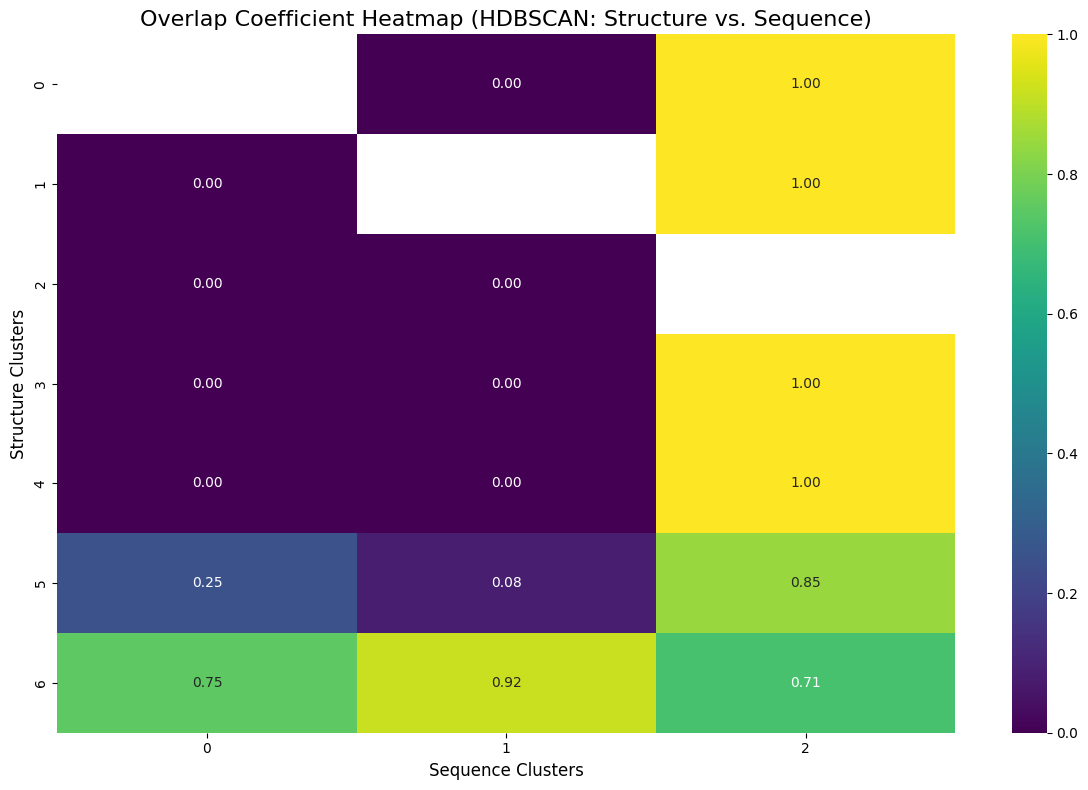

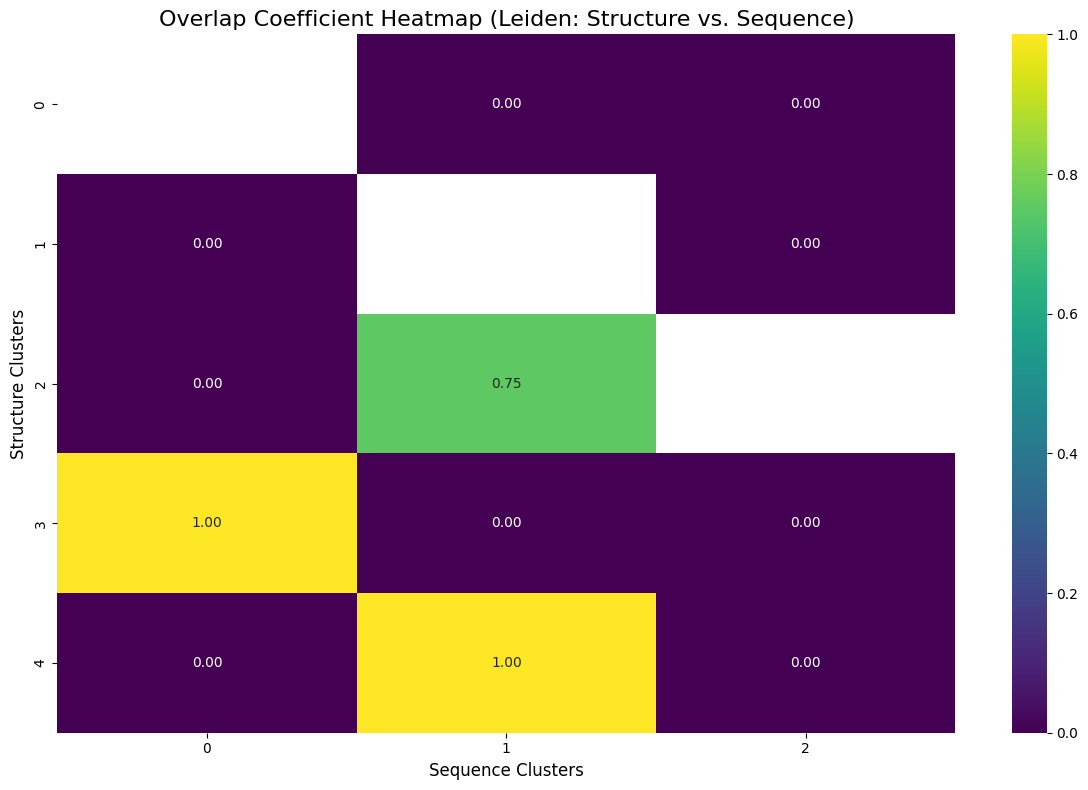

In [59]:
# Heatmap for Overlap coefficients HDBSCAN
overlap_pivot = overlap_coefficient_HDBSCAN.pivot(
    index='cluster_id_struct_HDBSCAN',
    columns='cluster_id_seq_HDBSCAN',
    values='OverlapCoefficient'
)
evaluator.visualizer.generate_heatmap(
    pivot_table=overlap_pivot,
    title='Overlap Coefficient Heatmap (HDBSCAN: Structure vs. Sequence)',
    x_label='Sequence Clusters',
    y_label='Structure Clusters'
)

# Heatmap for Overlap coefficients Leiden
overlap_pivot = overlap_coefficient_Leiden.pivot(
    index='cluster_id_Score_-log10_struct_Leiden',
    columns='cluster_id_Score_-log10_seq_Leiden',
    values='OverlapCoefficient'
)
evaluator.visualizer.generate_heatmap(
    pivot_table=overlap_pivot,
    title='Overlap Coefficient Heatmap (Leiden: Structure vs. Sequence)',
    x_label='Sequence Clusters',
    y_label='Structure Clusters'
)

### Interpretation

The overlap coefficient should show me there are structural clusters that are subsets of sequence clusters. (or the other way around)

In [30]:
# Compute statistics for each cluster for the different clustering methods

# statistics for HDBSCAN structure clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_struct_HDBSCAN",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_struct",
    df_scores=df_scores,
    score_col="Score_-log10_struct"
)
print("Cluster Statistics (HDBSCAN - structure):")
display(stats_per_cluster)

# statistics for HDBSCAN sequence clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_seq_HDBSCAN",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_seq",
    df_scores=df_scores,
    score_col="Score_-log10_seq"
)
print("Cluster Statistics (HDBSCAN - sequence):")
display(stats_per_cluster)

# statistics for Leiden structure clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_Score_-log10_struct_Leiden",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_struct",
    df_scores=df_scores,
    score_col="Score_-log10_struct"
)
print("Cluster Statistics (Leiden - structure):")
display(stats_per_cluster)

# statistics for Leiden sequence clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_Score_-log10_seq_Leiden",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_seq",
    df_scores=df_scores,
    score_col="Score_-log10_seq"
)
print("Cluster Statistics (Leiden - sequence):")
display(stats_per_cluster)

Cluster Statistics (HDBSCAN - structure):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,28,0.027642,9.962732
1,1,33,0.064159,9.893197
2,2,13,0.006822,10.041102
3,3,15,0.016687,10.127469
4,4,297,0.006444,10.209058
5,5,13,0.192796,8.232421
6,6,48,0.370343,7.804095


Cluster Statistics (HDBSCAN - sequence):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,10,0.307137,26.603189
1,1,15,0.044361,36.376263
2,2,468,0.010140,46.352968


Cluster Statistics (Leiden - structure):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,301,0.059360,10.192979
1,1,183,0.484072,8.634509
2,2,4,0.539877,9.472662
3,3,4,0.007077,10.107119
4,4,1,NaN,NaN


Cluster Statistics (Leiden - sequence):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,305,0.008621,48.872510
1,1,187,0.132505,39.940106
2,2,1,NaN,NaN


# next steps: 

1. create plots from:  

    jaccard index, cluster overlap coefficient for hdbscan and leiden for structure vs sequence based clustering  
    statistics for each cluster  

2. run evaluation with bigger dataset
    find pvalue then cluster

3. make sense of results